# Flow matching on Mnist dataset

In [1]:
import torch
from torch import nn, Tensor
from torch.nn import functional as F    
import torchvision 
from torchvision.datasets import MNIST
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import tqdm
from tqdm import tqdm
import time
import os
import sys
import datetime
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
batch_size = 32
num = 5
train_dataset = MNIST(root='./data', train=True, transform=torchvision.transforms.ToTensor(), download=True)
filtered_data = [(x, y) for x, y in train_dataset if y == num]
test_dataset = MNIST(root='./data', train=False, transform=torchvision.transforms.ToTensor(), download=True)
train_loader = DataLoader(dataset= filtered_data, batch_size= batch_size, shuffle=True)
test_loader = DataLoader(dataset= test_dataset, batch_size= batch_size, shuffle=False)

In [3]:
class Flow(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(2, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        self.enc3 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.Conv2d(256, 256, 3, padding=1), nn.ReLU())
        
        self.dec3 = nn.Sequential(nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(), nn.Conv2d(256, 128, 3, padding=1), nn.ReLU())
        self.dec2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 64, 3, padding=1), nn.ReLU())
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 1, 3, padding=1))
        
        self.time_emb = nn.Sequential(nn.Linear(1, 256), nn.ReLU(), nn.Linear(256, 256))
        
    def forward(self, x, t):
        t_emb = self.time_emb(t.view(-1, 1)).view(-1, 256, 1, 1)
        
        x = torch.cat([x, t.view(-1, 1, 1, 1).expand(-1, 1, 28, 28)], dim=1)
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2) + t_emb
        d3 = self.dec3(e3)
        d3 = nn.functional.interpolate(d3, scale_factor=2, mode='nearest')
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        d2 = nn.functional.interpolate(d2, scale_factor=2, mode='nearest')
        d1 = self.dec1(torch.cat([d2, e1], dim=1))
        return d1


    

In [4]:
from torchsummary import summary
model = Flow()
summary(model.to(device), [(1, 28, 28), (1,)])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]             512
              ReLU-2                  [-1, 256]               0
            Linear-3                  [-1, 256]          65,792
            Conv2d-4           [-1, 64, 28, 28]           1,216
              ReLU-5           [-1, 64, 28, 28]               0
            Conv2d-6           [-1, 64, 28, 28]          36,928
              ReLU-7           [-1, 64, 28, 28]               0
         MaxPool2d-8           [-1, 64, 14, 14]               0
            Conv2d-9          [-1, 128, 14, 14]          73,856
             ReLU-10          [-1, 128, 14, 14]               0
           Conv2d-11          [-1, 128, 14, 14]         147,584
             ReLU-12          [-1, 128, 14, 14]               0
        MaxPool2d-13            [-1, 128, 7, 7]               0
           Conv2d-14            [-1, 25

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [11]:
# training
num_epochs = 100
model = Flow().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.2)
loss_fn = nn.MSELoss()
sigma_m = 1e-8
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
    for images, _ in pbar:
        images = images.to(device)
        noise = torch.randn_like(images).to(device)

        t = torch.rand(images.size(0), 1).to(device)
        x_t = (1 - (1 - sigma_m)*t.view(-1,1,1,1))*noise + t.view(-1,1,1,1)*images
        u_true = images - noise 

        outputs = model(x_t, t)
        loss = loss_fn(outputs, u_true)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    scheduler.step()



Epoch 99: 100%|██████████| 170/170 [00:02<00:00, 60.21it/s, loss=0.0810]


In [12]:
torch.save(model.state_dict(), f"model_{num}.pth")

In [ ]:
model = Flow().to(device)
model.load_state_dict(torch.load(f"model_{num}.pth"))
model.eval()

tensor([0.9899, 0.9899, 0.9899, 0.9899, 0.9899, 0.9899, 0.9899, 0.9899, 0.9899,
        0.9899, 0.9899, 0.9899, 0.9899, 0.9899, 0.9899, 0.9899],
       device='cuda:0')

In [12]:
# Generate samples
import numpy as np
steps = 200
print("\nGenerating samples...")
model.eval()
with torch.no_grad():
    x_0 = torch.randn(16, 1, 28, 28, device=device)
    T = np.linspace(0, 1, steps)
    x_t = x_0    
    for step in range(steps-1):
        t_start = torch.tensor(T[step], dtype=torch.float32).expand(16).to(device)
        t_end = torch.tensor(T[step+1], dtype=torch.float32).expand(16).to(device)
        
        x_t = x_t + (t_end-t_start).view(-1,1,1,1) * model(
            x_t + model(x_t, t_start) * ((t_end-t_start)/2).view(-1,1,1,1),
            t_start + (t_end-t_start)/2
        )
    
    samples = x_t.cpu()


Generating samples...


In [53]:
len(train_dataset)

60000

Train data


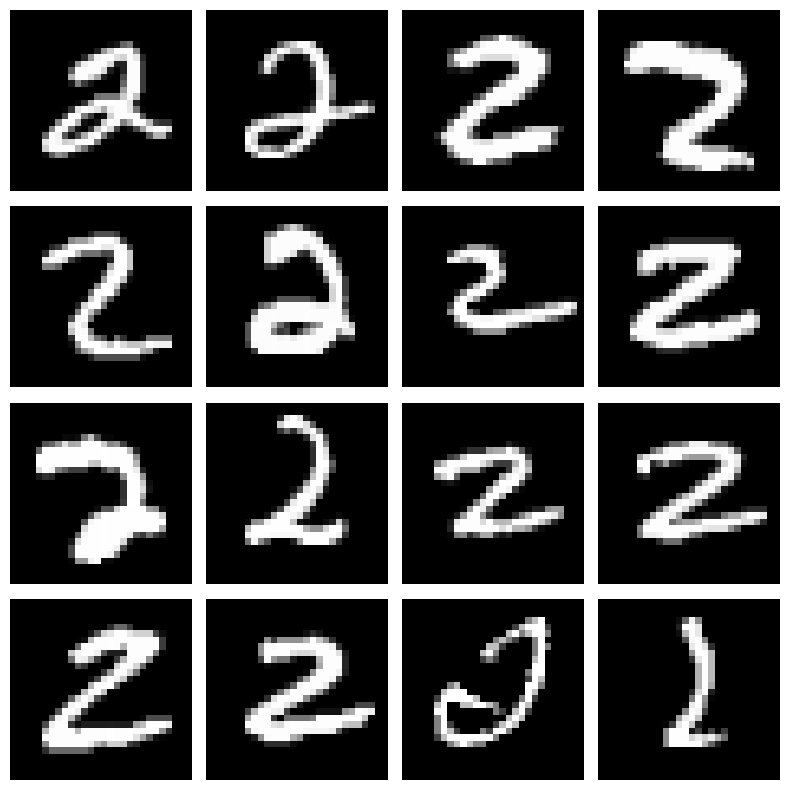

In [69]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
image_init = filtered_data[:16]
for i, ax in enumerate(axes.flat):
    ax.imshow(image_init[i][0].squeeze().cpu(), cmap='gray')
    ax.axis('off')
print("Train data")
plt.tight_layout()
plt.show()

Samples saved to flow_matching_samples.png


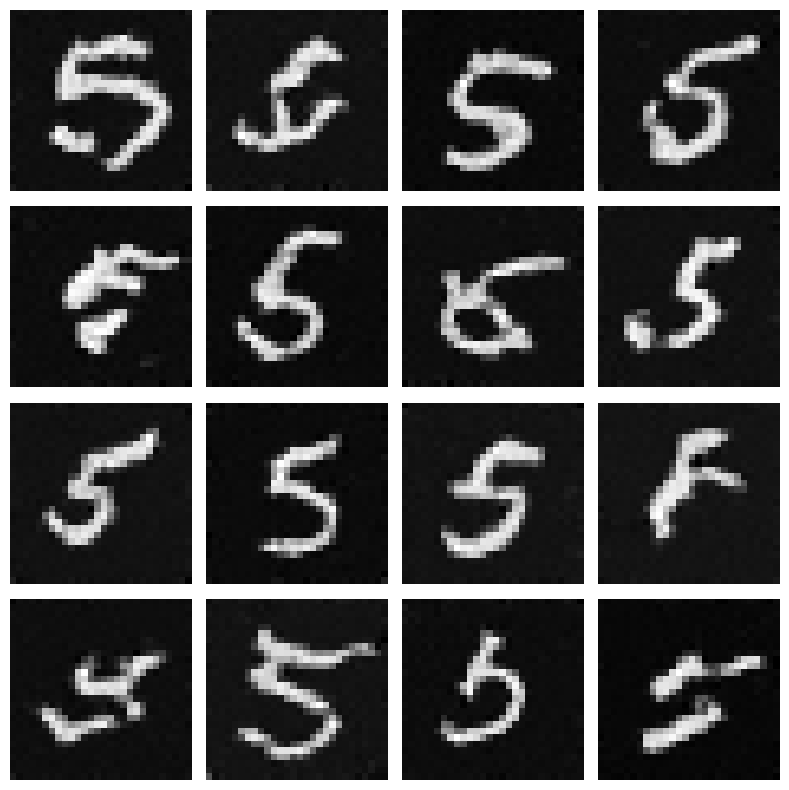

In [13]:
# Display
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0], cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.savefig('flow_matching_samples.png')
print("Samples saved to flow_matching_samples.png")
plt.show()


Generating sample with animation...
Saved as mnist_sampling.gif


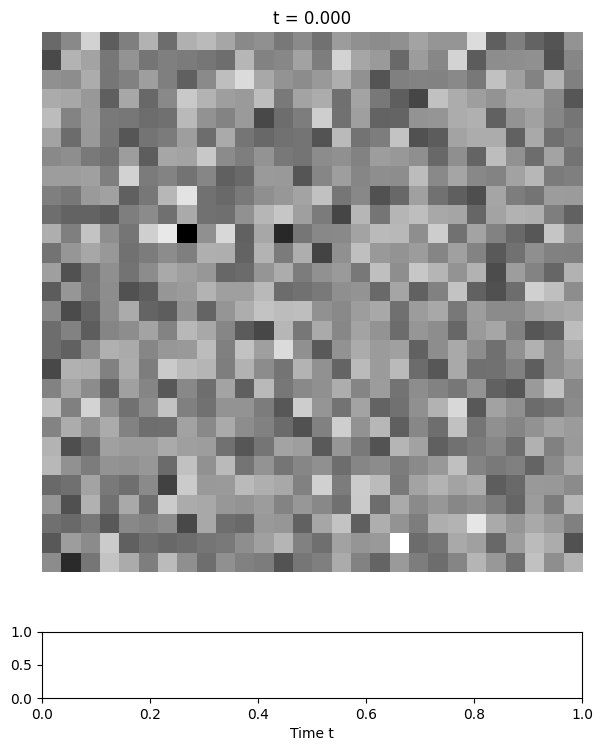

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import PillowWriter

steps = 200
save_every = steps // 20  # Capture ~20 frames

print("\nGenerating sample with animation...")
model.eval()

frames = []
time_steps = []

with torch.no_grad():
    x_0 = torch.randn(1, 1, 28, 28, device=device)
    T = np.linspace(0, 1, steps)
    x_t = x_0
    
    for step in range(steps-1):
        if step % save_every == 0:
            frames.append(x_t.cpu().squeeze().numpy())
            time_steps.append(T[step])
        
        t_start = torch.tensor(T[step], dtype=torch.float32).expand(1).to(device)
        t_end = torch.tensor(T[step+1], dtype=torch.float32).expand(1).to(device)
        
        x_t = x_t + (t_end-t_start).view(-1,1,1,1) * model(
            x_t + model(x_t, t_start) * ((t_end-t_start)/2).view(-1,1,1,1),
            t_start + (t_end-t_start)/2
        )
    
    frames.append(x_t.cpu().squeeze().numpy())
    time_steps.append(T[-1])

# Create animation
fig, (ax_img, ax_bar) = plt.subplots(2, 1, figsize=(6, 8), 
                                      gridspec_kw={'height_ratios': [10, 1]})

im = ax_img.imshow(frames[0], cmap='gray')
ax_img.axis('off')
ax_img.set_title(f't = {time_steps[0]:.3f}')

ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.set_xlabel('Time t')
bar_fill = ax_bar.barh(0.5, 0, height=0.5, color='blue')

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax_img.set_title(f't = {time_steps[frame_idx]:.3f}')
    bar_fill[0].set_width(time_steps[frame_idx])

ani = FuncAnimation(fig, update, frames=len(frames), interval=200)
plt.tight_layout()

# Save as GIF
writer = PillowWriter(fps=5)
ani.save('mnist_sampling.gif', writer=writer, dpi=100)
print("Saved as mnist_sampling.gif")

In [10]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

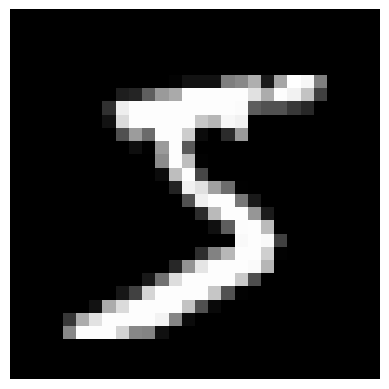

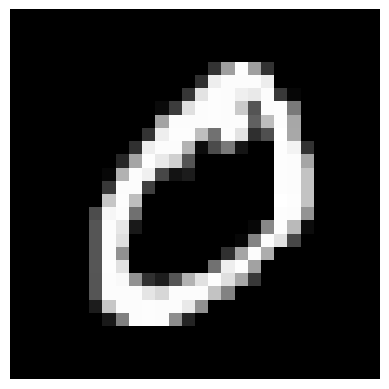

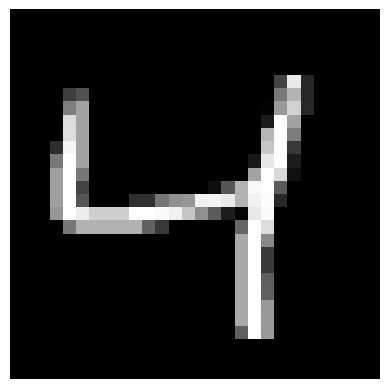

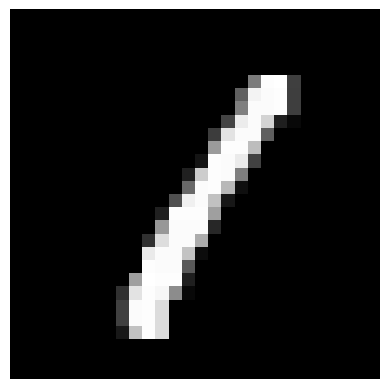

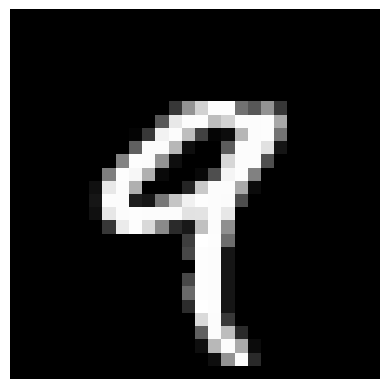

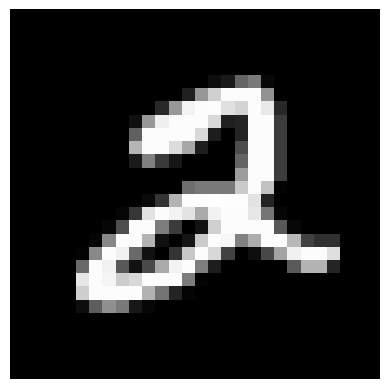

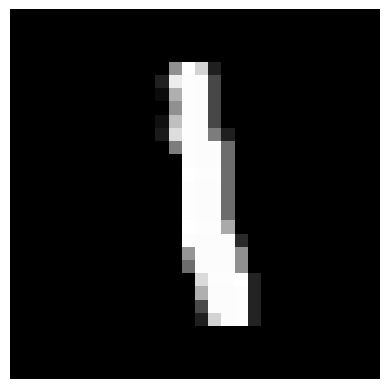

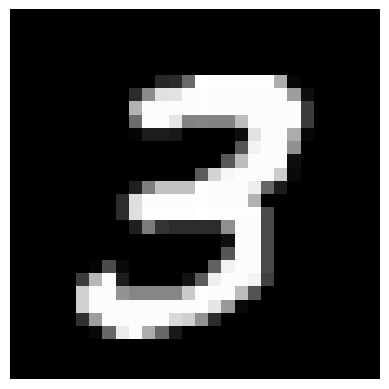

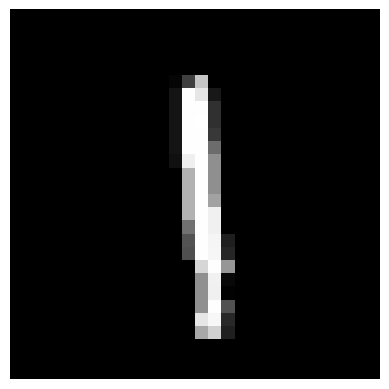

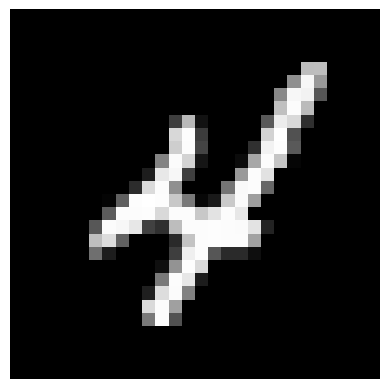

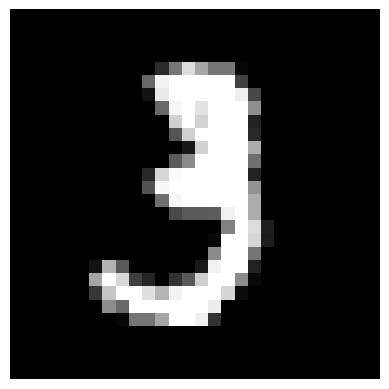

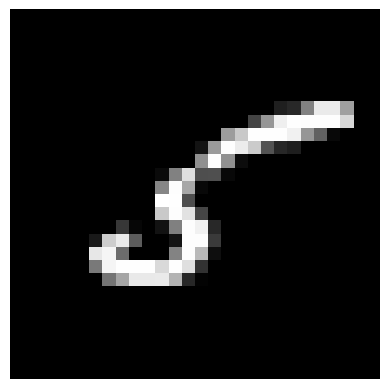

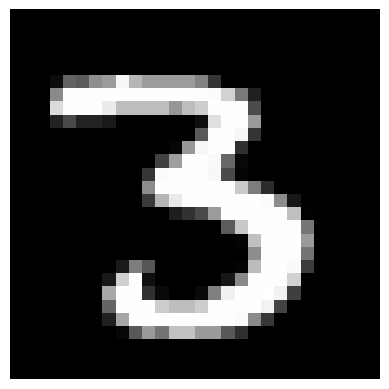

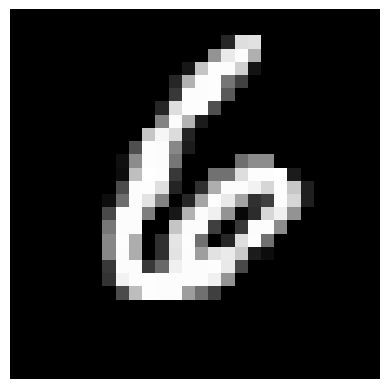

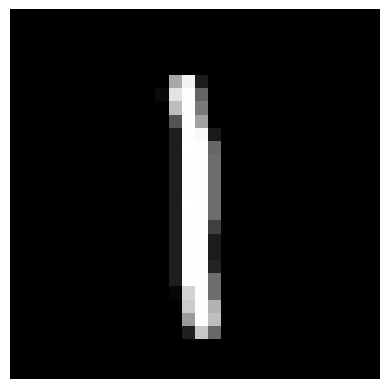

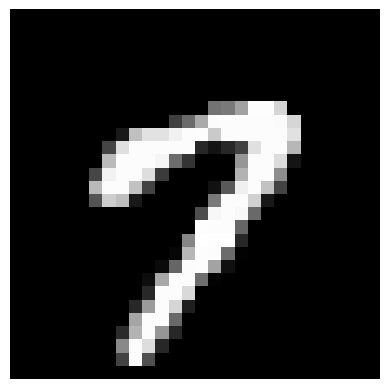

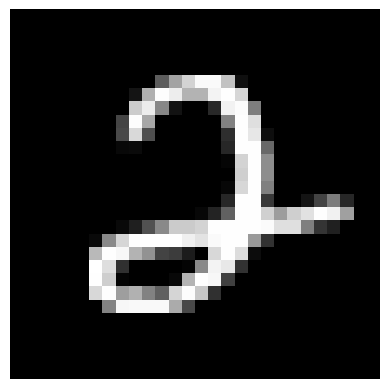

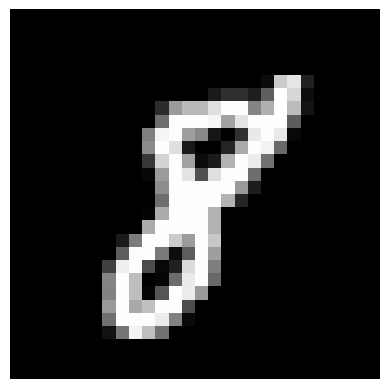

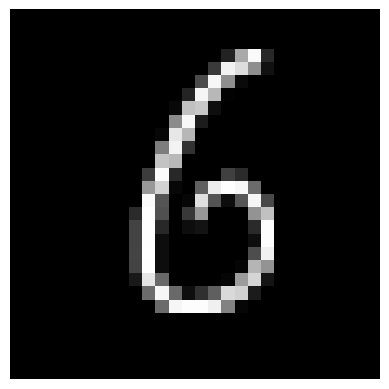

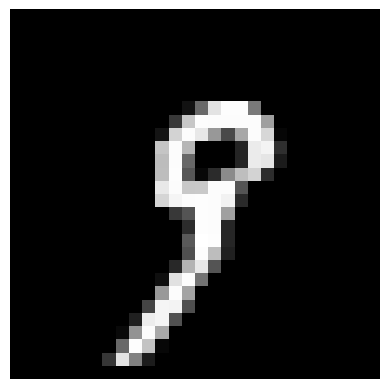

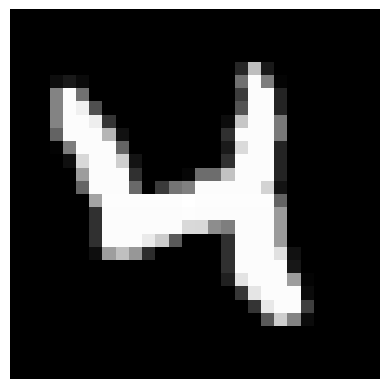

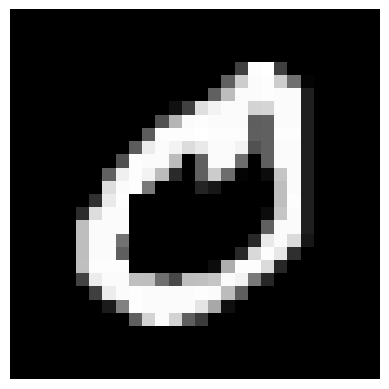

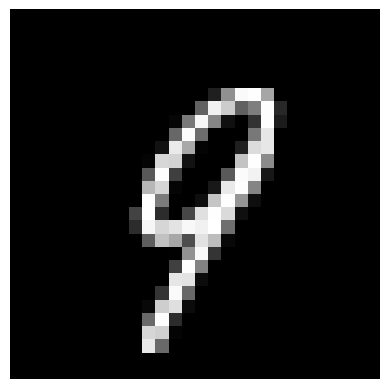

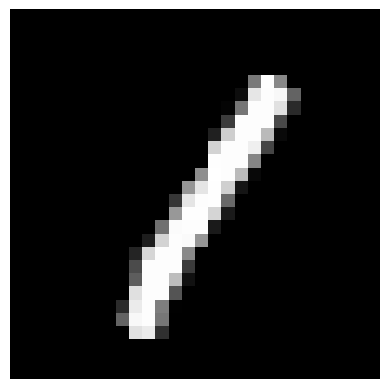

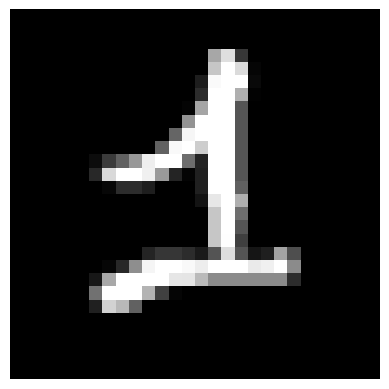

In [15]:
for i in range(25):
    plt.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()